# Módulo 2: Vectorización de Texto y Modelos Clásicos

Cómo pasar de palabras a números, y cómo entrenar clasificadores con esas representaciones.

## 2.1 Representación Numérica del Texto

### Bag of Words (BoW)

El modelo más simple: **ignorar el orden** de las palabras y contar cuántas veces aparece cada una.

In [1]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np

corpus = [
    "I love this movie",
    "I hate this movie",
    "This movie is great",
    "I love great food",
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)
vocab = vectorizer.get_feature_names_out()

df = pd.DataFrame(X.toarray(), columns=vocab,
                  index=[f"Doc {i+1}" for i in range(len(corpus))])
print("Matriz BoW:")
df

Matriz BoW:


,food,great,hate,is,love,movie,this
Doc 1,0,0,0,0,1,1,1
Doc 2,0,0,1,0,0,1,1
Doc 3,0,1,0,1,0,1,1
Doc 4,1,1,0,0,1,0,0


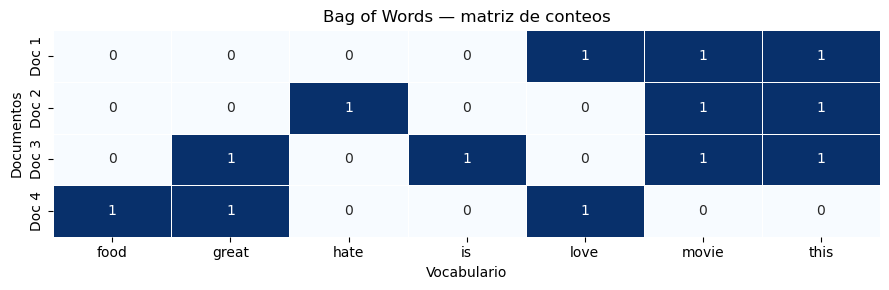

**Limitaciones de BoW:**
- Ignora el orden de las palabras (`"I love" ≠ "love I"`)
- Palabras frecuentes dominan el vector aunque sean poco informativas
- Vectores muy dispersos (mayoría de ceros)

### TF-IDF

**TF-IDF** pondera cada término por su *rareza* en el corpus. Una palabra que aparece en todos los documentos aporta poco.

$$\text{TF-IDF}(t, d) = \underbrace{\frac{f_{t,d}}{\sum_k f_{k,d}}}_{\text{TF}} \times \underbrace{\log\frac{N}{df_t}}_{\text{IDF}}$$

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(corpus)
vocab_tfidf = tfidf.get_feature_names_out()

df_tfidf = pd.DataFrame(
    X_tfidf.toarray().round(3), columns=vocab_tfidf,
    index=[f"Doc {i+1}" for i in range(len(corpus))]
)
print("Matriz TF-IDF:")
df_tfidf

Matriz TF-IDF:


,food,great,hate,is,love,movie,this
Doc 1,0.000,0.000,0.000,0.000,0.658,0.533,0.533
Doc 2,0.000,0.000,0.742,0.000,0.000,0.474,0.474
Doc 3,0.000,0.505,0.000,0.641,0.000,0.409,0.409
Doc 4,0.668,0.526,0.000,0.000,0.526,0.000,0.000


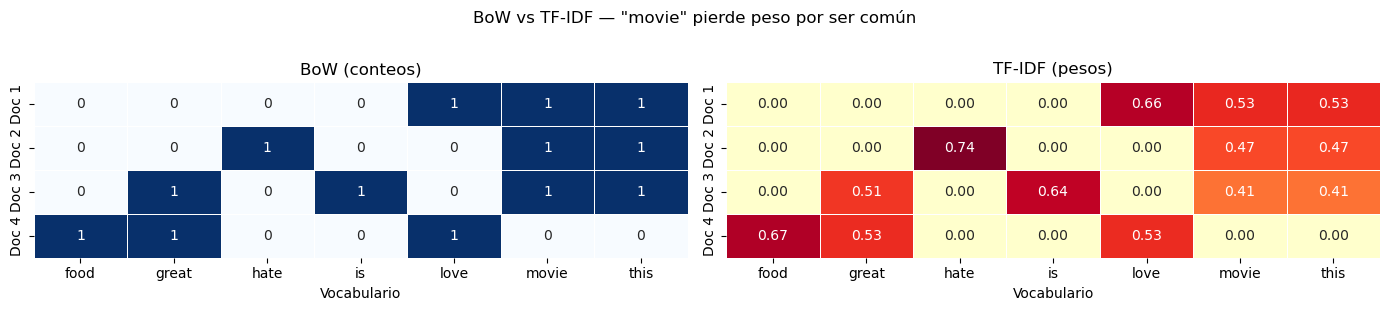

### N-gramas

Los **n-gramas** capturan contexto local al incluir secuencias de *n* palabras consecutivas.

In [5]:
texto = "not good at all"

for n in [1, 2, 3]:
    vec = CountVectorizer(ngram_range=(n, n))
    vec.fit([texto])
    nombre = {1: 'Unigramas', 2: 'Bigramas', 3: 'Trigramas'}[n]
    print(f"{nombre:10}: {list(vec.vocabulary_.keys())}")

Unigramas : ['not', 'good', 'at', 'all']
Bigramas  : ['not good', 'good at', 'at all']
Trigramas : ['not good at', 'good at all']


In [6]:
# Importancia de bigramas para sentimientos
frases_ngram = [
    "the movie was not good",
    "the movie was very good",
    "not bad at all",
]

vec_bi = CountVectorizer(ngram_range=(1, 2))
X_bi = vec_bi.fit_transform(frases_ngram)
features = vec_bi.get_feature_names_out()

df_bi = pd.DataFrame(X_bi.toarray(), columns=features,
                     index=[f"'{f}'" for f in frases_ngram])

# Solo mostrar columnas con valores > 0 en al menos 1 doc
mask = df_bi.sum(axis=0) > 0
print("\nN-gramas relevantes:")
print(df_bi.loc[:, mask].to_string())
print("\n► 'not good' y 'not bad' son bigramas que NLTK/BoW simple no distinguiría")


N-gramas relevantes:
                           all  at  at all  bad  bad at  good  movie  movie was  not  not bad  not good  the  the movie  very  very good  was  was not  was very
'the movie was not good'     0   0       0    0       0     1      1          1    1        0         1    1          1     0          0    1        1         0
'the movie was very good'    0   0       0    0       0     1      1          1    0        0         0    1          1     1          1    1        0         1
'not bad at all'             1   1       1    1       1     0      0          0    1        1         0    0          0     0          0    0        0         0

► 'not good' y 'not bad' son bigramas que NLTK/BoW simple no distinguiría


---
## 2.2 Clasificación de Texto con Machine Learning

### Pipeline de clasificación

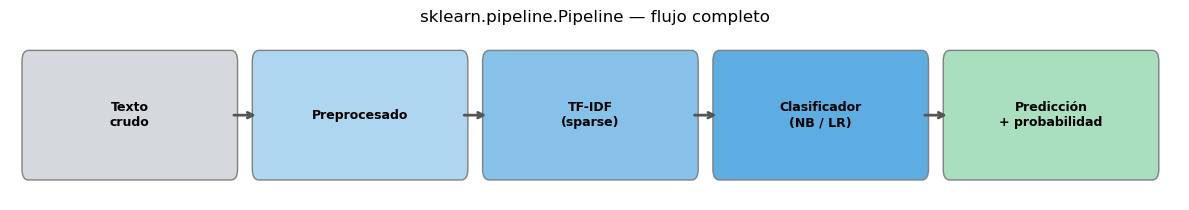

### Entrenamiento: Naive Bayes y Regresión Logística

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Dataset de ejemplo (simulado — reseñas de películas)
reseñas = [
    "This movie is fantastic and amazing",
    "What a great film, loved it",
    "Absolutely brilliant performance by all actors",
    "Wonderful story and beautiful cinematography",
    "One of the best movies I have ever seen",
    "Incredible experience from start to finish",
    "Terrible film, waste of time and money",
    "Boring and predictable plot, very disappointing",
    "Bad acting, poor script and awful direction",
    "Worst movie ever, completely unwatchable",
    "A dull and lifeless production",
    "Not worth watching at all, very bad",
]
etiquetas = [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]  # 1=positivo, 0=negativo

X_train, X_test, y_train, y_test = train_test_split(
    reseñas, etiquetas, test_size=0.25, random_state=42, stratify=etiquetas
)

# Pipeline Naive Bayes
pipe_nb = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
    ('nb',    MultinomialNB()),
])
pipe_nb.fit(X_train, y_train)

# Pipeline Regresión Logística
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
    ('lr',    LogisticRegression(max_iter=1000)),
])
pipe_lr.fit(X_train, y_train)

print("=== Naive Bayes ===")
print(classification_report(y_test, pipe_nb.predict(X_test),
                             target_names=['Negativo', 'Positivo']))
print("=== Regresión Logística ===")
print(classification_report(y_test, pipe_lr.predict(X_test),
                             target_names=['Negativo', 'Positivo']))

=== Naive Bayes ===
              precision    recall  f1-score   support

    Negativo       0.00      0.00      0.00       2.0
    Positivo       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0

=== Regresión Logística ===
              precision    recall  f1-score   support

    Negativo       0.00      0.00      0.00         2
    Positivo       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

### Métricas de evaluación

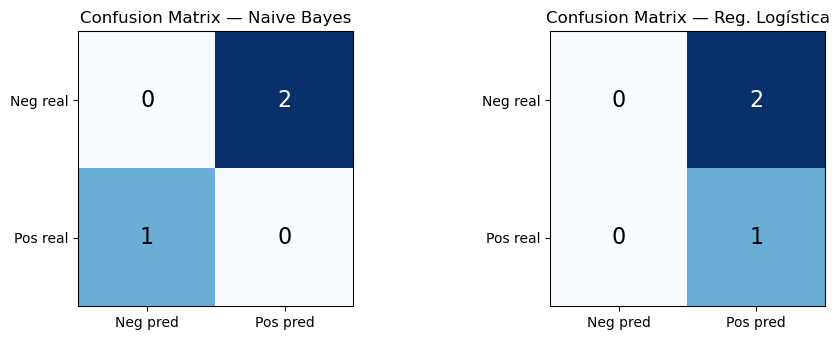

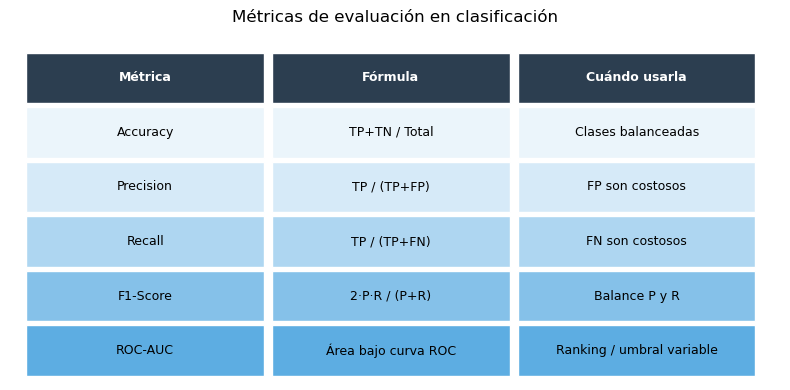

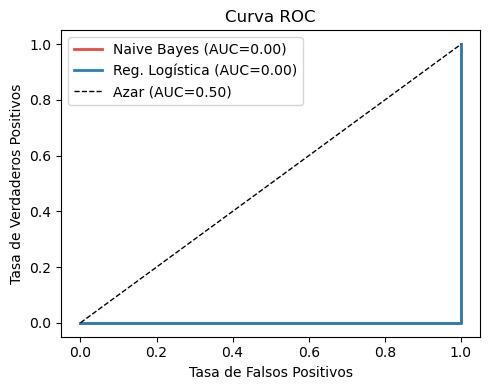

### Comparativa: Naive Bayes vs Regresión Logística

| Aspecto | Naive Bayes | Regresión Logística |
|---------|-------------|---------------------|
| **Supuesto** | Features independientes (incorrecto en texto) | Sin supuesto de independencia |
| **Velocidad** | Muy rápido | Más lento (optimización iterativa) |
| **Datos escasos** | Funciona bien con pocos datos | Necesita más datos |
| **Rendimiento** | Bueno como baseline | Generalmente mejor que NB |
| **Interpretabilidad** | Alta (probabilidades de log) | Alta (coeficientes) |